In [1]:
import pandas as pd
import os
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [32]:
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0001")

In [33]:
file_path="21600-0001-Data.tsv"

In [34]:
df1 = pd.read_csv(file_path, sep='\t', low_memory=False)

In [69]:
df_all=pd.read_csv('W1-4_fulldata.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_17444\3597778550.py:1: DtypeWarning: Columns (7,125,126,197,199,357,514,523,524,744,746,747,833,834,838,839,840,847,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,957,958,965,970,971,973,977,978,980,982,983,985,1001,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1064,1066,1069,1070,1071,1072,1075,1076,1077,1078,1082,1083,1084,1085,1086,1088,1089,1090,1110,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1152,1175,1176,1177,1178,1181,1182,1183,1184,1185,1188,1189,1190,1191,1192,1210,1212,1213,1226,1227,1228,1229,1230,1231,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1291,1293,1374,1375,1381,1397,1398,1399,1400,1401,1402,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433,143

In [78]:
for c in df_all.columns:
    if "age" in c.lower():
        print(c)


Age when Moved to Current Residence
Age_StartedSmoking
Age_FirstDrinkNoAdults
Age at First Drink
Age_FirstMarijuana
Age_FirstCocaine
Age_StartedSmoking_Z
Age_FirstDrinkNoAdults_Z
Age_StartedSmoking_rev_Z
Age_FirstDrinkNoAdults_rev_Z
Age_StartRegularSmoking
Age_FirstWholeCig


In [77]:
df_all['Age at First Drink'].describe()

count    2029.000000
mean       14.595367
std         2.137391
min         8.000000
25%        13.000000
50%        15.000000
75%        16.000000
max        20.000000
Name: Age at First Drink, dtype: float64

In [68]:
df_all['IYEAR'].describe()

count    5114.000000
mean       94.999804
std         0.013984
min        94.000000
25%        95.000000
50%        95.000000
75%        95.000000
max        95.000000
Name: IYEAR, dtype: float64

In [2]:
df_all_filtered=pd.read_csv('W1-4_fulldata_filtered.csv')

In [4]:
print([col for col in df_all_filtered.columns if 'index' in col.lower()])


['GPA_Index', 'SchoolTrouble_Index', 'DisciplinaryIndex', 'ParentalWarmth_Index', 'ParentalSupervision_Index', 'Delinquency_Index', 'SportsParticipation_Index', 'MentalDistress_Index', 'SES_Index', 'SexAttitudes_Index', 'SchoolTrouble_Index_Z', 'SchoolBehavior_Index', 'PeerSubstance_Index', 'NeighborhoodCohesion_Index', 'ParentalSupport_Index', 'Support_Index', 'LowReligiosityIndex_W1']


In [7]:
len(df_all_filtered.columns)

210

In [3]:
df_all_filtered = df_all_filtered.drop(columns=["DaysMarijuanaPast12M_W4"], errors="ignore")


In [4]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "TotalDrinking"  
corr_thr = 0.09                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_all_filtered.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_filtered = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 49 vars with |corr| ≥ 0.090
[Step 2] Dropped 19 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 30

=== FINAL FEATURE SET ===
Variables kept (n=30):
Sex_Female
SexAttitudes_Index
SchoolSuspension_Z
Delinquency_Index
SchoolBehavior_Index
Age at First Drink
SchoolTrouble_Index
PeerSubstance_Index
InjuredSomeone
LessLonely_Sex
FriendsRespect_Sex
GPA_Index
Rev_FeelGuilty_Sex
Relax_Sex_Z
SoldDrugs_Z
WantCollege_W1
EverTried_Cigarette_Z
Trouble Paying Attention
PhysicalFight_W1
Attractive_Sex
ExpectCollege_W1
LowReligiosityIndex_W1
Fight_Serious_Z
Trouble_GetAlong_Teachers_W1
Pleasure_Sex
FriendCare_W1
WeaponThreat_W1
DrinkFrequency_Past12mo
HighEduExpectations
Jumped_W1


In [5]:
df = df_filtered.copy()


In [6]:
df.head()

,Sex_Female,SexAttitudes_Index,SchoolSuspension_Z,Delinquency_Index,SchoolBehavior_Index,Age at First Drink,SchoolTrouble_Index,PeerSubstance_Index,InjuredSomeone,LessLonely_Sex,...,LowReligiosityIndex_W1,Fight_Serious_Z,Trouble_GetAlong_Teachers_W1,Pleasure_Sex,FriendCare_W1,WeaponThreat_W1,DrinkFrequency_Past12mo,HighEduExpectations,Jumped_W1,TotalDrinking
0,1,0.704868,-0.607756,0.284682,0.467625,16.0,1.75,2.666667,1.0,2.0,...,NaN,-0.580644,2.0,4.0,5.0,0.0,3.0,0,0.0,25.0
2,0,NaN,1.645398,0.624930,0.406031,12.0,1.75,1.333333,1.0,NaN,...,0.740869,2.045035,2.0,NaN,5.0,0.0,3.0,0,0.0,48.0
3,0,NaN,-0.607756,-0.167422,-0.159368,NaN,1.75,0.000000,0.0,NaN,...,0.266794,0.732195,1.0,NaN,4.0,0.0,NaN,1,0.0,72.0
4,0,0.415719,1.645398,-0.351844,0.210727,NaN,0.75,0.000000,0.0,2.0,...,-0.207282,-0.580644,1.0,3.0,3.0,1.0,NaN,1,0.0,2.0
6,1,NaN,-0.607756,-0.331527,-0.309846,NaN,1.00,0.000000,0.0,NaN,...,-0.872646,-0.580644,1.0,NaN,4.0,0.0,NaN,1,0.0,2.5


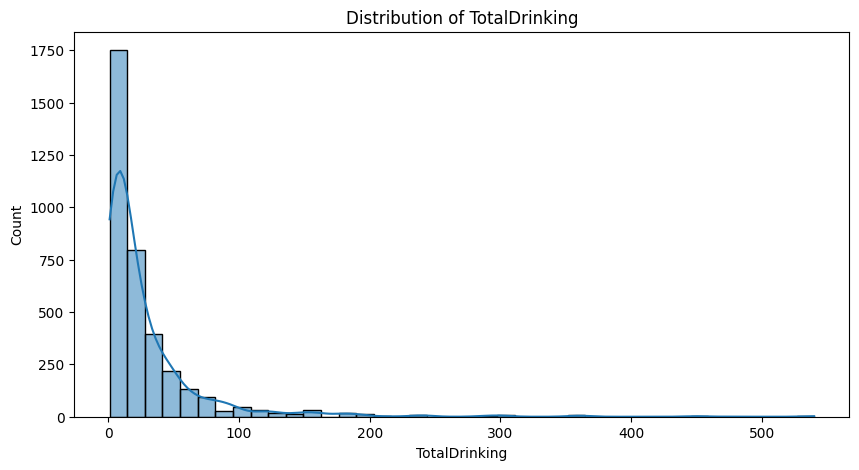

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["TotalDrinking"], kde=True, bins=40)
plt.title("Distribution of TotalDrinking")
plt.show()




In [9]:
df = df[df["TotalDrinking"].notna()].copy()


In [10]:
df["heavy_drinker"] = (df["TotalDrinking"] > 40).astype(int)


In [11]:
y = df["heavy_drinker"]

X = df.drop(columns=["TotalDrinking", "heavy_drinker"])


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [13]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
heavy_drinker
0    2207
1     514
Name: count, dtype: int64

Test class counts:
heavy_drinker
0    736
1    172
Name: count, dtype: int64


## Modeling

## catboost

In [23]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    class_weights=[1, 5],    # this helps imbalance
    
)

# parameter grid
param_grid = {
    'depth': [4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'iterations': [300, 500, 800],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 5, 10],
}

cat.grid_search(param_grid, train_pool,cv=3,stratified=True, verbose=False)



bestTest = 0.7197103193
bestIteration = 291

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7298749302
bestIteration = 211

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7291872609
bestIteration = 106

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7157239868
bestIteration = 37

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7226329136
bestIteration = 298

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7198392573
bestIteration = 167

Metric AUC is not calculated on train by default. To ca

{'params': {'bagging_temperature': 0,
  'depth': 6,
  'learning_rate': 0.05,
  'l2_leaf_reg': 7,
  'iterations': 300},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
        

In [24]:
print("Best depth:", cat.get_param("depth"))
print("Best learning_rate:", cat.get_param("learning_rate"))
print("Best iterations:", cat.get_param("iterations"))
print("Best l2_leaf_reg:", cat.get_param("l2_leaf_reg"))
print("Best bagging_temperature:", cat.get_param("bagging_temperature"))



Best depth: 6
Best learning_rate: 0.05
Best iterations: 300
Best l2_leaf_reg: 7
Best bagging_temperature: 0


In [19]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ----------------------------
# 1) Best params (from your grid_search)
# ----------------------------
best_params = {
    'depth': 6,
    'iterations': 300,
    'learning_rate': 0.05,
    'l2_leaf_reg': 7,
    'bagging_temperature': 0,
    'class_weights': [1, 5],
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 2) Compute CV-based Youden threshold on TRAIN ONLY (OOF probs)
# ----------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], tpr[idx], 1 - fpr[idx], j[idx]

# Ensure y_train is a numpy array for indexing
y_train_np = np.asarray(y_train)

# If X_train is a pandas DataFrame, use .iloc; otherwise fallback to array indexing
X_train_is_df = hasattr(X_train, "iloc")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(y_train_np), dtype=float)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train_np), start=1):
    if X_train_is_df:
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    else:
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]

    y_tr, y_val = y_train_np[tr_idx], y_train_np[val_idx]

    model = CatBoostClassifier(**best_params)
    model.fit(X_tr, y_tr)

    oof_prob[val_idx] = model.predict_proba(X_val)[:, 1]

best_threshold, sens, spec, j = youden_threshold(y_train_np, oof_prob)

print(f"CV-Youden threshold (train OOF): {best_threshold:.4f}")
print(f"Sensitivity at threshold:        {sens:.4f}")
print(f"Specificity at threshold:        {spec:.4f}")
print(f"Youden's J:                      {j:.4f}")

# ----------------------------
# 3) Fit FINAL model on FULL TRAIN set with best_params
# ----------------------------
cat_final = CatBoostClassifier(**best_params)
cat_final.fit(X_train, y_train)

# ----------------------------
# 4) Evaluate on TEST using frozen threshold
# ----------------------------
y_prob_test = cat_final.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test, digits=3))
print("Test AUC:", roc_auc_score(y_test, y_prob_test))


CV-Youden threshold (train OOF): 0.3639
Sensitivity at threshold:        0.6751
Specificity at threshold:        0.6416
Youden's J:                      0.3167

Confusion Matrix:
 [[436 300]
 [ 51 121]]

Classification Report:
               precision    recall  f1-score   support

           0      0.895     0.592     0.713       736
           1      0.287     0.703     0.408       172

    accuracy                          0.613       908
   macro avg      0.591     0.648     0.561       908
weighted avg      0.780     0.613     0.655       908

Test AUC: 0.683218528816987


## XGBoost with tuning

In [25]:
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()


In [28]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

# ----------------------------
# 0) Hyperparameter search space
# ----------------------------
param_dist = {
    "n_estimators": randint(300, 900),
    "learning_rate": uniform(0.01, 0.1),
    "max_depth": randint(3, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

# ----------------------------
# 1) Base model
# ----------------------------
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# 2) Hyperparameter tuning with CV=3 (TRAIN ONLY)
# ----------------------------
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_xgb, y_train)

print("Best CV AUC:", random_search.best_score_)
print("Best Parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_  # already refit=True by default

# ----------------------------
# 3) Compute Youden threshold correctly using CV=5 OOF probs on TRAIN ONLY
# ----------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]

y_train_np = np.asarray(y_train)
X_is_df = hasattr(X_train_xgb, "iloc")

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(y_train_np), dtype=float)

for tr_idx, val_idx in skf5.split(X_train_xgb, y_train_np):
    if X_is_df:
        X_tr, X_val = X_train_xgb.iloc[tr_idx], X_train_xgb.iloc[val_idx]
    else:
        X_tr, X_val = X_train_xgb[tr_idx], X_train_xgb[val_idx]

    y_tr, y_val = y_train_np[tr_idx], y_train_np[val_idx]

    # IMPORTANT: use the same best hyperparameters found above
    fold_model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),  # fold-specific (optional but fine)
        random_state=42,
        n_jobs=-1,
        **random_search.best_params_
    )

    fold_model.fit(X_tr, y_tr)
    oof_prob[val_idx] = fold_model.predict_proba(X_val)[:, 1]

best_threshold, best_j, sens, spec = youden_threshold(y_train_np, oof_prob)

print("\n=======================================")
print(" Youden threshold (CV=5, TRAIN OOF):", round(best_threshold, 4))
print(" Youden J (TRAIN OOF):", round(best_j, 4))
print(" Sensitivity @ thr:", round(sens, 4))
print(" Specificity @ thr:", round(spec, 4))
print("=======================================")

# ----------------------------
# 4) Fit FINAL model on FULL TRAIN (best params), then test evaluation
# ----------------------------
best_xgb.fit(X_train_xgb, y_train)

y_prob = best_xgb.predict_proba(X_test_xgb)[:, 1]
auc = roc_auc_score(y_test, y_prob)

y_pred = (y_prob >= best_threshold).astype(int)

print("\n=======================================")
print(" XGBoost Test AUC:", round(auc, 4))
print("=======================================")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV AUC: 0.7164168513774042
Best Parameters:
{'colsample_bytree': np.float64(0.6296178606936361), 'gamma': np.float64(1.7923286427213632), 'learning_rate': np.float64(0.021586905952512975), 'max_depth': 3, 'min_child_weight': 8, 'n_estimators': 332, 'subsample': np.float64(0.6254233401144095)}

 Youden threshold (CV=5, TRAIN OOF): 0.4243
 Youden J (TRAIN OOF): 0.3378
 Sensitivity @ thr: 0.7315
 Specificity @ thr: 0.6063

 XGBoost Test AUC: 0.7006

Confusion Matrix:
 [[430 306]
 [ 47 125]]

Classification Report:
               precision    recall  f1-score   support

           0      0.901     0.584     0.709       736
           1      0.290     0.727     0.415       172

    accuracy                          0.611       908
   macro avg      0.596     0.655     0.562       908
weighted avg      0.786     0.611     0.653       908



Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV AUC: 0.7164
Best Parameters:
{'colsample_bytree': np.float64(0.6296178606936361), 'gamma': np.float64(1.7923286427213632), 'learning_rate': np.float64(0.021586905952512975), 'max_depth': 3, 'min_child_weight': 8, 'n_estimators': 332, 'subsample': np.float64(0.6254233401144095)}

 Youden threshold (CV=5, TRAIN OOF): 0.4243
 Youden J (TRAIN OOF): 0.3378
 Sensitivity @ thr: 0.7315
 Specificity @ thr: 0.6063

 XGBoost Test AUC: 0.7006
 XGBoost Test Avg Precision (PR-AUC): 0.3203
 Threshold used (Youden, train OOF): 0.4243

Confusion Matrix:
 [[430 306]
 [ 47 125]]

Classification Report:
               precision    recall  f1-score   support

           0      0.901     0.584     0.709       736
           1      0.290     0.727     0.415       172

    accuracy                          0.611       908
   macro avg      0.596     0.655     0.562       908
weighted avg      0.786     0.611     0.653       908



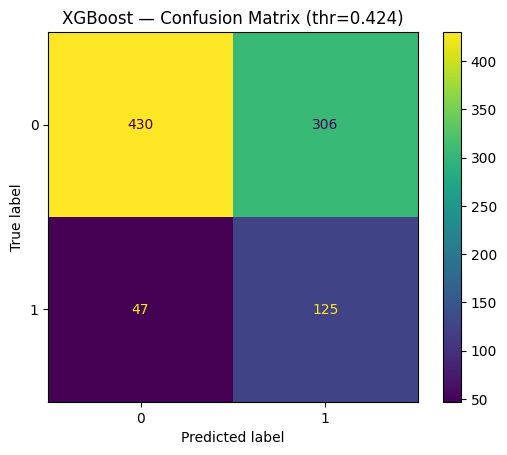

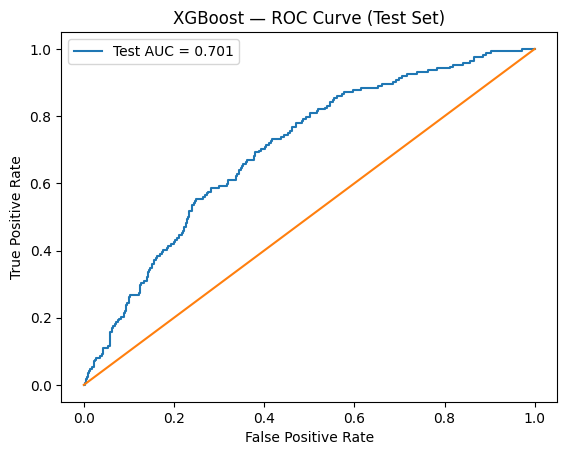

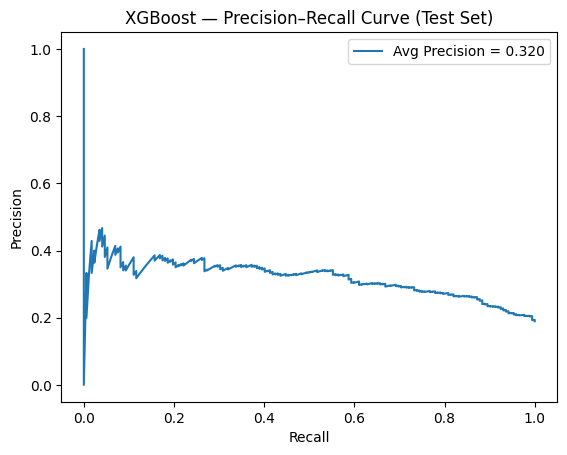

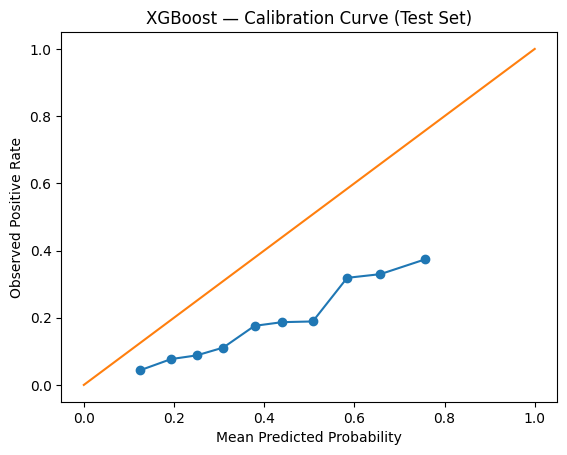

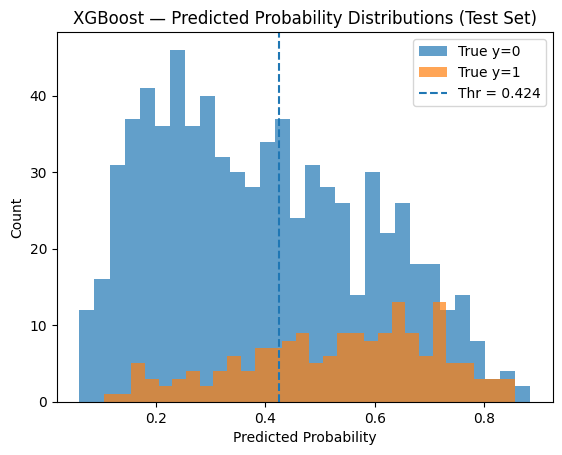

In [47]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN THRESHOLD (CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ----------------------------
# 0) Hyperparameter search space
# ----------------------------
param_dist = {
    "n_estimators": randint(300, 900),
    "learning_rate": uniform(0.01, 0.1),
    "max_depth": randint(3, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

# ----------------------------
# 1) Base model
# ----------------------------
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# 2) Hyperparameter tuning with CV=3 (TRAIN ONLY)
# ----------------------------
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_xgb, y_train)

print("Best CV AUC:", round(random_search.best_score_, 4))
print("Best Parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_  # refit=True by default

# ----------------------------
# 3) Compute Youden threshold correctly using CV=5 OOF probs on TRAIN ONLY
# ----------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]

y_train_np = np.asarray(y_train)
X_is_df = hasattr(X_train_xgb, "iloc")

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(y_train_np), dtype=float)

for tr_idx, val_idx in skf5.split(X_train_xgb, y_train_np):
    if X_is_df:
        X_tr, X_val = X_train_xgb.iloc[tr_idx], X_train_xgb.iloc[val_idx]
    else:
        X_tr, X_val = X_train_xgb[tr_idx], X_train_xgb[val_idx]

    y_tr = y_train_np[tr_idx]

    fold_model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),  # fold-specific
        random_state=42,
        n_jobs=-1,
        **random_search.best_params_
    )

    fold_model.fit(X_tr, y_tr)
    oof_prob[val_idx] = fold_model.predict_proba(X_val)[:, 1]

best_threshold, best_j, sens, spec = youden_threshold(y_train_np, oof_prob)

print("\n=======================================")
print(" Youden threshold (CV=5, TRAIN OOF):", round(best_threshold, 4))
print(" Youden J (TRAIN OOF):", round(best_j, 4))
print(" Sensitivity @ thr:", round(sens, 4))
print(" Specificity @ thr:", round(spec, 4))
print("=======================================")

# ----------------------------
# 4) Fit FINAL model on FULL TRAIN, then test evaluation (single report)
# ----------------------------
# NOTE: best_xgb is already refit by RandomizedSearchCV, but re-fitting is harmless
best_xgb.fit(X_train_xgb, y_train)

y_prob = best_xgb.predict_proba(X_test_xgb)[:, 1]
auc = roc_auc_score(y_test, y_prob)

y_pred = (y_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

ap = average_precision_score(y_test, y_prob)

print("\n=======================================")
print(" XGBoost Test AUC:", round(auc, 4))
print(" XGBoost Test Avg Precision (PR-AUC):", round(ap, 4))
print(" Threshold used (Youden, train OOF):", round(best_threshold, 4))
print("=======================================")

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 Colored Confusion Matrix (Matplotlib colormap)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={best_threshold:.3f})")
plt.show()

# 5.2 ROC Curve (Test)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 Precision–Recall Curve (Test)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 Calibration Curve (Test)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 Probability Distributions (Test) + threshold line
y_test_np = np.asarray(y_test)

plt.figure()
plt.hist(y_prob[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_threshold, linestyle="--", label=f"Thr = {best_threshold:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

performance_table = pd.DataFrame({
    "Metric": [
        "AUC",
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)"
    ],
    "Value": [
        auc,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

performance_table


,Metric,Value
0,AUC,0.700597
1,Accuracy,0.611233
2,Precision (Class 1),0.290023
3,Recall (Class 1),0.726744
4,F1-score (Class 1),0.414594


In [30]:
booster = best_xgb.get_booster()
gain_dict = booster.get_score(importance_type="gain")

importance_df = (
    pd.DataFrame.from_dict(gain_dict, orient="index", columns=["Gain"])
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("Gain", ascending=False)
)

importance_df["Gain_pct"] = importance_df["Gain"] / importance_df["Gain"].sum()

importance_df.head(20)


,Feature,Gain,Gain_pct
0,Sex_Female,58.450340,0.133517
5,Age at First Drink,20.693062,0.047269
2,SchoolSuspension_Z,16.663424,0.038064
19,Attractive_Sex,15.476296,0.035352
17,Trouble Paying Attention,15.129164,0.034559
21,LowReligiosityIndex_W1,14.488310,0.033095
6,SchoolTrouble_Index,14.386622,0.032863
23,Trouble_GetAlong_Teachers_W1,14.385983,0.032862
27,DrinkFrequency_Past12mo,14.195820,0.032427
3,Delinquency_Index,14.110605,0.032233


X_bg_np dtype: float32
X_test_np dtype: float32


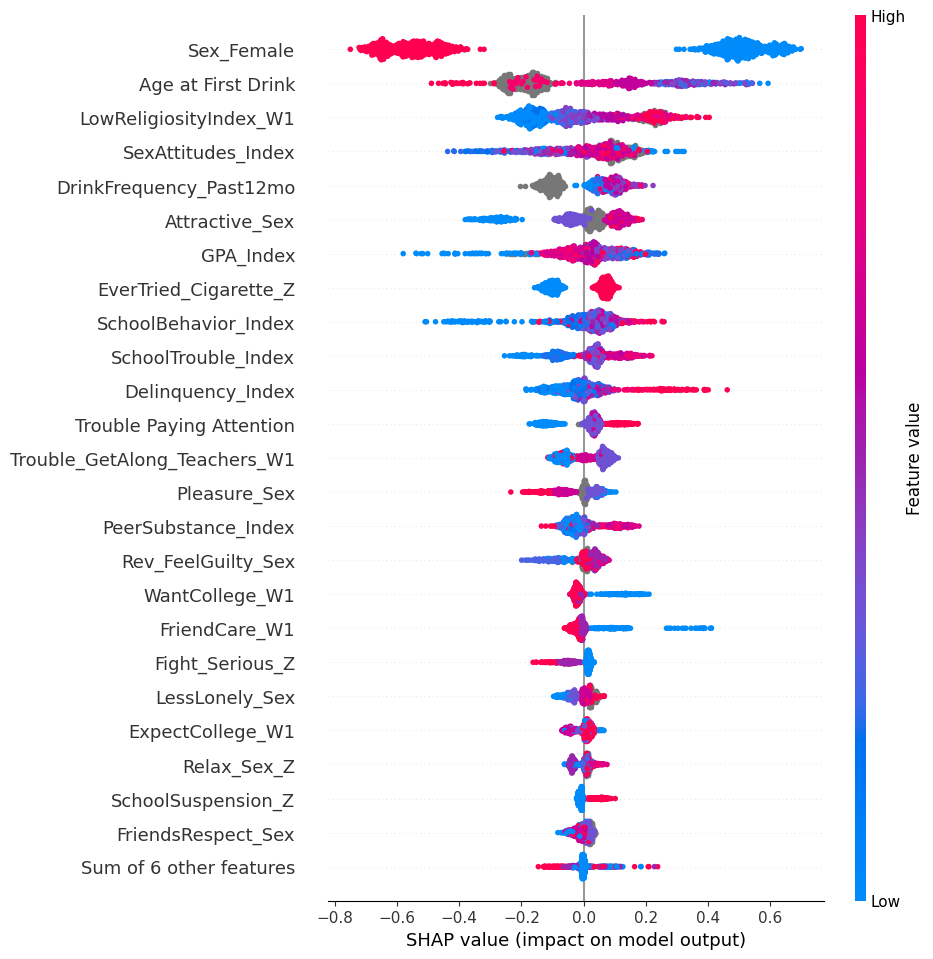

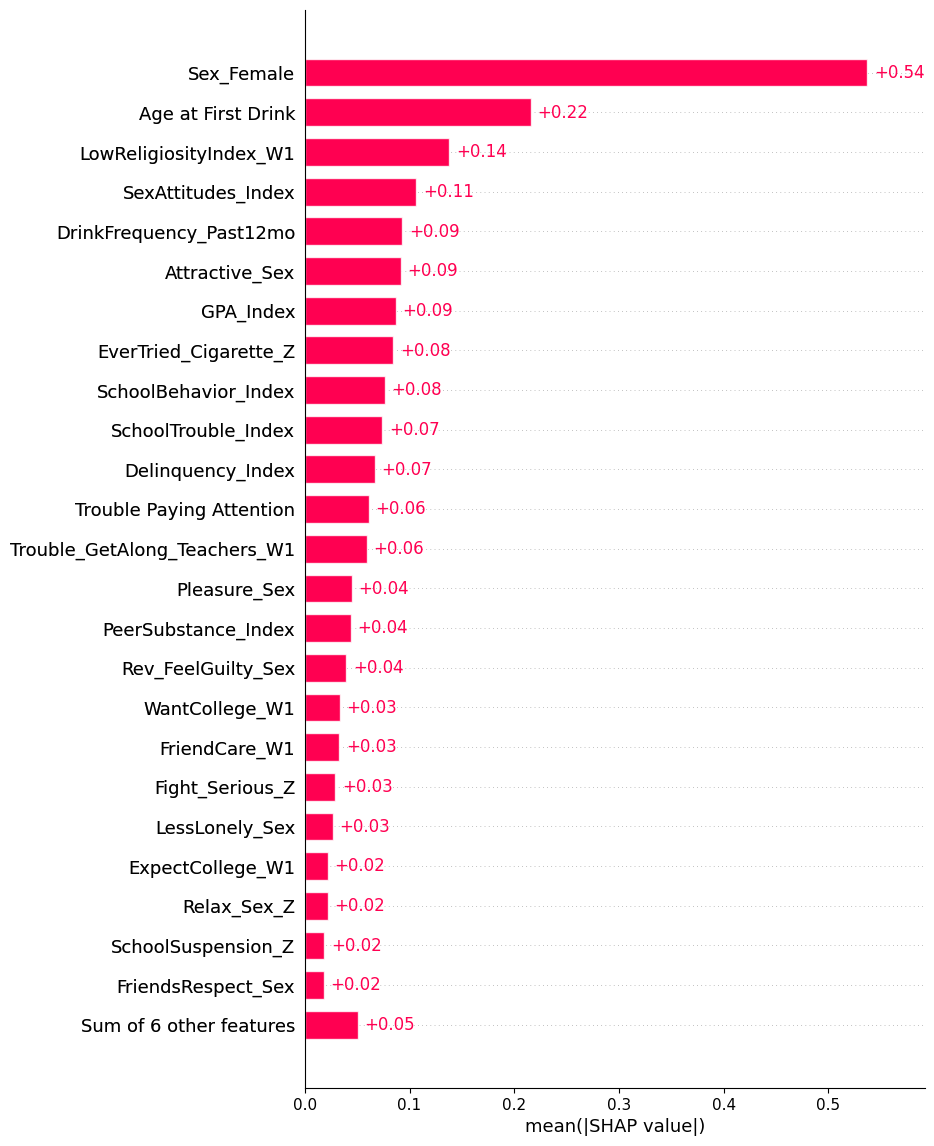

Top SHAP features: ['Sex_Female', 'Age at First Drink', 'LowReligiosityIndex_W1', 'SexAttitudes_Index', 'DrinkFrequency_Past12mo', 'Attractive_Sex', 'GPA_Index', 'EverTried_Cigarette_Z', 'SchoolBehavior_Index', 'SchoolTrouble_Index']


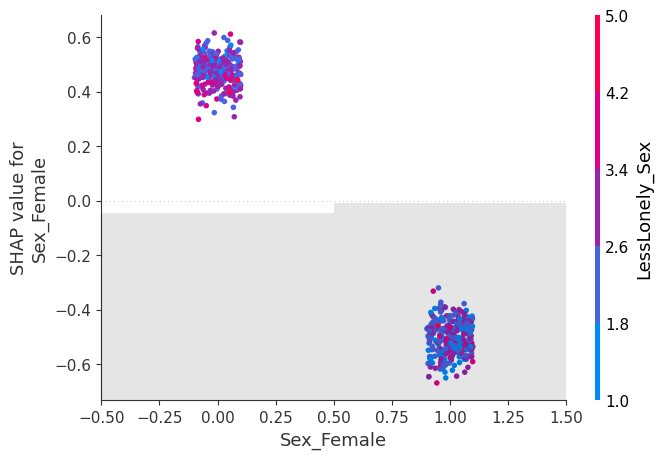

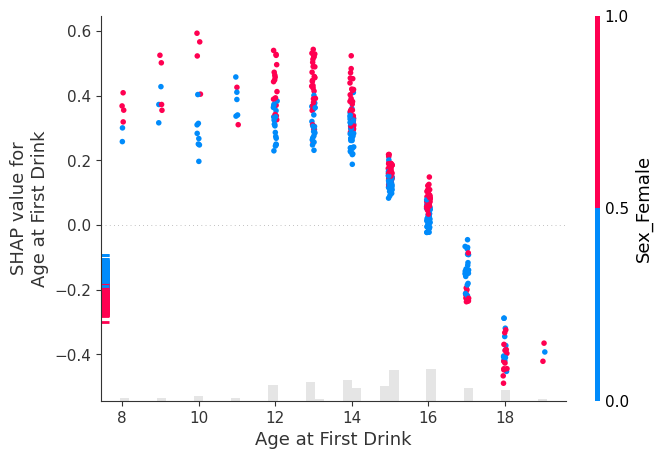

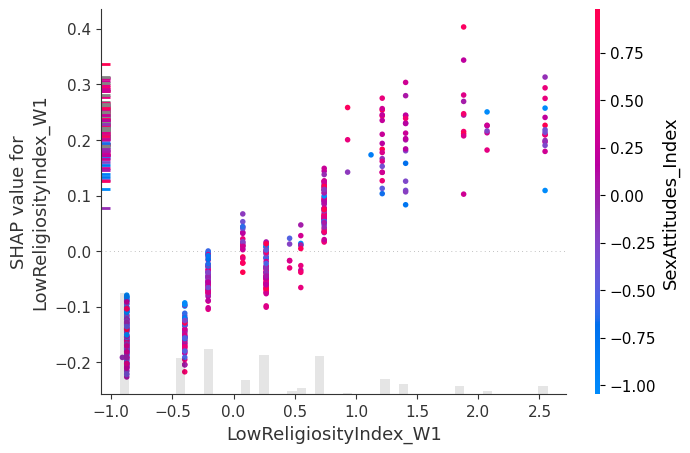

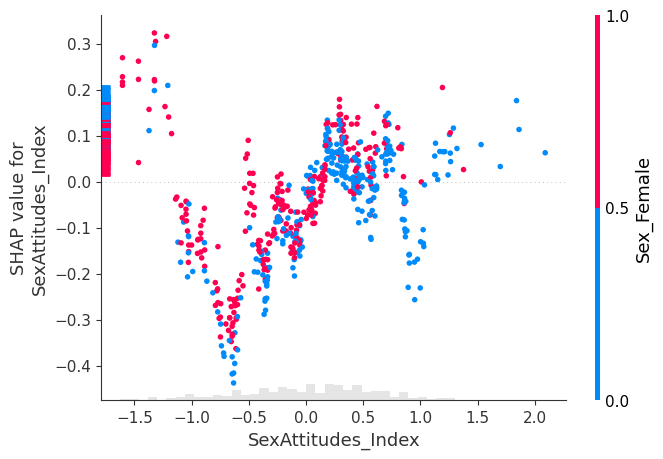

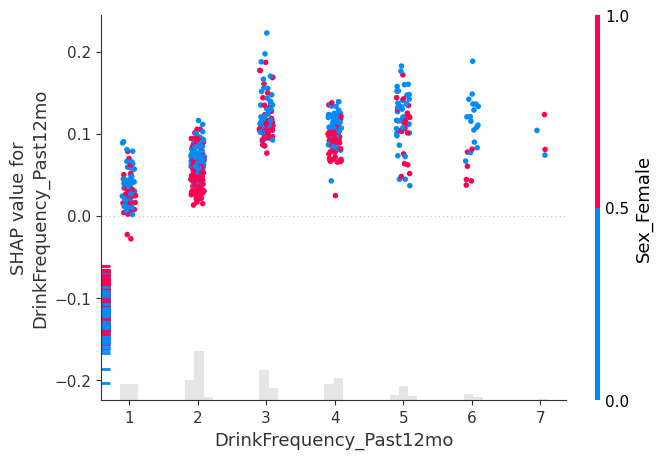

Explaining test row index: 325


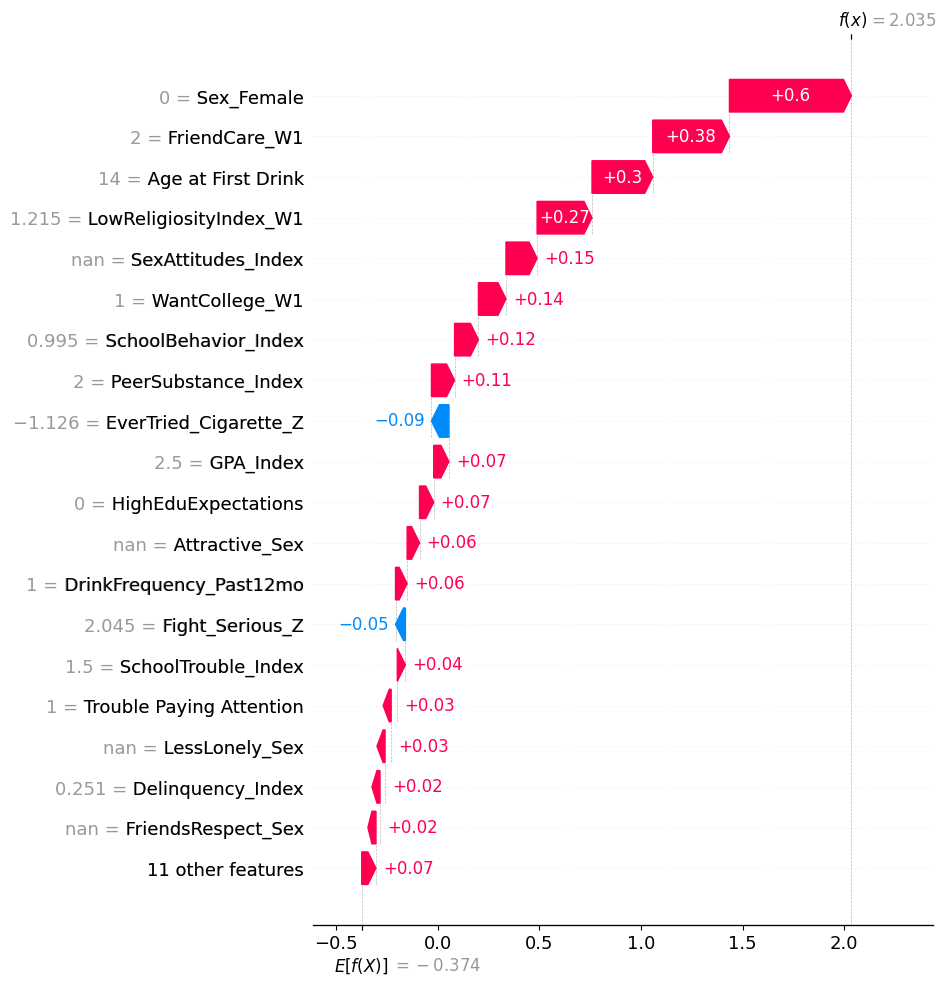

In [31]:
# ============================
# SHAP analysis for best_xgb
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Make sure X_* are DataFrames (keeps feature names for plots)
if not isinstance(X_train_xgb, pd.DataFrame):
    X_train_xgb = pd.DataFrame(X_train_xgb)
if not isinstance(X_test_xgb, pd.DataFrame):
    X_test_xgb = pd.DataFrame(X_test_xgb)

# (Optional but recommended) background sample for speed/stability
bg_size = min(500, len(X_train_xgb))
X_bg = X_train_xgb.sample(bg_size, random_state=42)


import numpy as np
import shap

feature_names = X_train_xgb.columns.tolist()

# 1) Convert bool -> int, then force everything to float32
def force_float32(df):
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)
    return df.astype(np.float32)

X_train_shap = force_float32(X_train_xgb)
X_test_shap  = force_float32(X_test_xgb)

# 2) Background sample
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

# 3) Convert to numpy float32 (NOW it won't be object)
X_bg_np   = X_bg.to_numpy(dtype=np.float32)
X_test_np = X_test_shap.to_numpy(dtype=np.float32)

print("X_bg_np dtype:", X_bg_np.dtype)
print("X_test_np dtype:", X_test_np.dtype)

# 4) SHAP
explainer = shap.Explainer(best_xgb, X_bg_np, feature_names=feature_names)
shap_values = explainer(X_test_np)

shap.plots.beeswarm(shap_values, max_display=25)




# (Alternative global view: mean(|SHAP|) bar)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
# Get top features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_xgb.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

# Dependence plots for top features
for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose an instance index (e.g., highest predicted risk)
idx = int(np.argmax(best_xgb.predict_proba(X_test_xgb)[:, 1]))
print("Explaining test row index:", idx)

# Waterfall plot for that instance
shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks; may need JS init)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_xgb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=X_test_xgb.columns)
shap_df["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]
shap_df["y_true"] = np.array(y_test)

# Save if you want
# shap_df.to_csv("shap_values_test.csv", index=False)


In [32]:
# SHAP values array: (n_samples, n_features)
S = shap_values.values

# Optional but recommended: standardize
from sklearn.preprocessing import StandardScaler
S_scaled = StandardScaler().fit_transform(S)


In [33]:
from sklearn.cluster import KMeans

k = 4  # start here
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
archetypes = kmeans.fit_predict(S_scaled)


In [34]:
df_archetypes = X_test_xgb.copy()
df_archetypes["archetype"] = archetypes
df_archetypes["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]


In [35]:
import pandas as pd
import numpy as np

archetype_profiles = (
    pd.DataFrame(S, columns=feature_names)
      .assign(archetype=archetypes)
      .groupby("archetype")
      .mean()
)

archetype_profiles


,Sex_Female,SexAttitudes_Index,SchoolSuspension_Z,Delinquency_Index,SchoolBehavior_Index,Age at First Drink,SchoolTrouble_Index,PeerSubstance_Index,InjuredSomeone,LessLonely_Sex,...,ExpectCollege_W1,LowReligiosityIndex_W1,Fight_Serious_Z,Trouble_GetAlong_Teachers_W1,Pleasure_Sex,FriendCare_W1,WeaponThreat_W1,DrinkFrequency_Past12mo,HighEduExpectations,Jumped_W1
archetype,,,,,,,,,,,,,,,,,,,,,
0,0.024658,0.040662,0.005120,0.014093,0.034660,0.143103,0.054944,0.029440,-0.001678,0.001586,...,-0.005624,0.057689,-0.002799,0.018417,-0.031209,0.002625,-0.000871,0.069376,0.004529,0.001110
1,-0.110712,0.090274,-0.004044,-0.032843,-0.004600,-0.156219,-0.009011,-0.023522,-0.000923,0.021883,...,0.000673,-0.042017,0.003091,0.000315,-0.007642,0.003892,-0.000529,-0.064632,-0.007663,0.001456
2,0.230192,0.017501,0.028402,0.132789,0.037310,0.004085,0.054545,0.014295,0.006179,-0.002848,...,-0.009386,0.043694,-0.064613,0.029808,-0.023568,0.036053,0.008955,0.046936,0.005796,-0.008595
3,-0.130610,-0.110427,-0.004107,-0.027025,-0.024203,-0.048576,-0.024068,-0.019651,-0.001712,-0.037693,...,0.003696,-0.041850,0.006193,-0.006672,0.008208,-0.006538,-0.001235,-0.010075,-0.006793,0.001476



Archetype 0


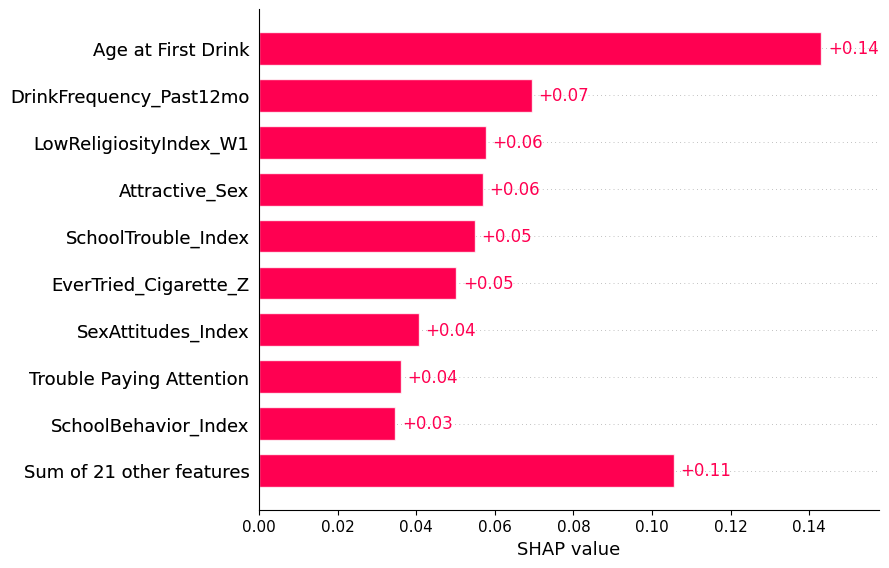


Archetype 1


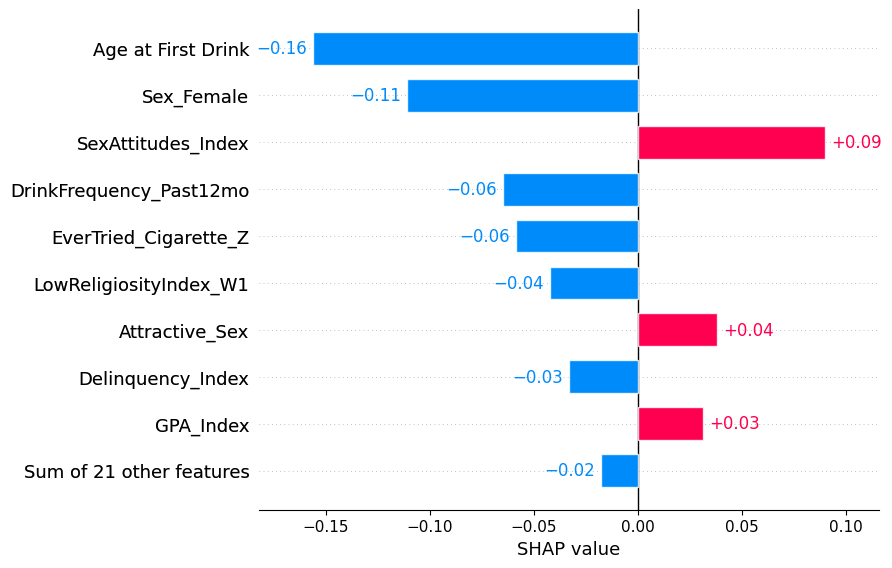


Archetype 2


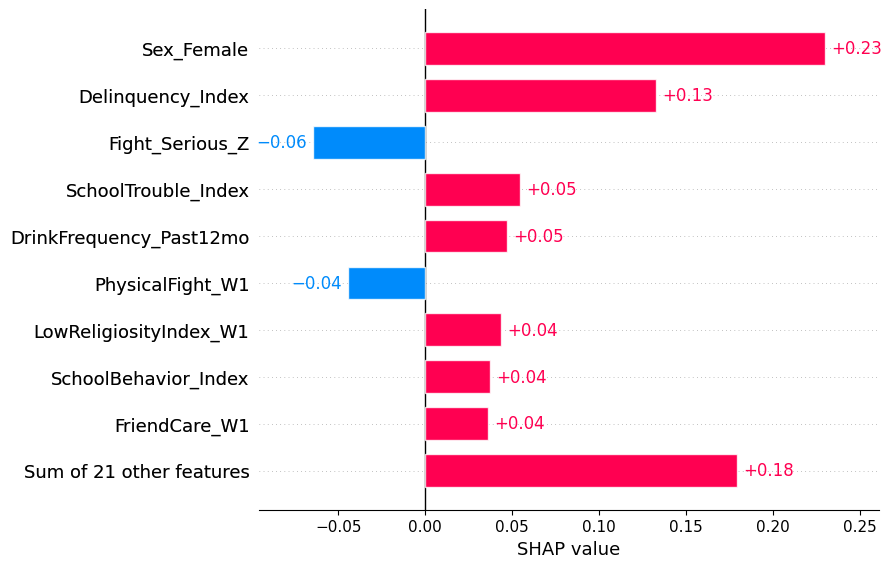


Archetype 3


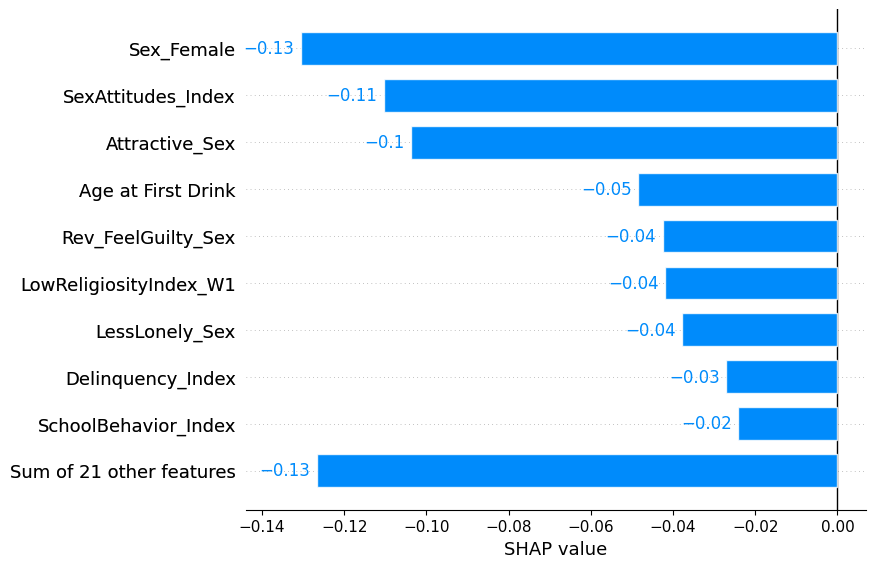

In [36]:
for a in sorted(df_archetypes["archetype"].unique()):
    print(f"\nArchetype {a}")
    shap.plots.bar(
        shap.Explanation(
            values=archetype_profiles.loc[a].values,
            feature_names=feature_names
        ),
        max_display=10
    )


In [37]:
df_archetypes.groupby("archetype")["pred_prob"].describe()


,count,mean,std,min,25%,50%,75%,max
archetype,,,,,,,,
0,265.0,0.561415,0.154458,0.238507,0.438797,0.575204,0.688273,0.884433
1,291.0,0.353018,0.170997,0.068848,0.213576,0.312595,0.498220,0.767560
2,115.0,0.564639,0.165298,0.159302,0.451526,0.591672,0.692978,0.825670
3,237.0,0.275265,0.125602,0.060186,0.171179,0.268421,0.362403,0.634129


## Logistic (L2)

In [38]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# ------------------------------------------------------------
# 0) Copies (as you had)
# ------------------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)

# ------------------------------------------------------------
# 1) Helper: Youden threshold
# ------------------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]

# ------------------------------------------------------------
# 2) CV object (use CV=5 consistently for thresholding)
# ------------------------------------------------------------
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 3) TUNED Logistic Regression (L2) using LogisticRegressionCV
#    - tuning is done INSIDE training only
# ------------------------------------------------------------
# Pipeline: impute -> scale -> tuned LR
pipe_lr_cv = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 30),      # grid of inverse regularization strengths
        cv=3,                           # tuning CV (you can set to 3 for speed)
        penalty="l2",
        solver="liblinear",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        refit=True
    ))
])

# Fit tuned model on FULL TRAIN (this is your final LR model)
pipe_lr_cv.fit(X_train2, y_train)

# Best C found (optional print)
best_C = pipe_lr_cv.named_steps["lr"].C_[0]
print("Best C (from tuning):", best_C)

# ------------------------------------------------------------
# 4) Youden threshold the RIGHT way:
#    - compute OOF probabilities on TRAIN only using CV=5
#    - use the tuned pipeline as the estimator in CV
# ------------------------------------------------------------
# cross_val_predict will refit the estimator in each fold (required for OOF)
oof_prob = cross_val_predict(
    pipe_lr_cv, X_train2, y_train,
    cv=cv5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (CV=5, TRAIN OOF):", round(best_thr, 4))
print(" Youden J (TRAIN OOF):", round(best_j, 4))
print(" Sensitivity @ thr:", round(sens, 4))
print(" Specificity @ thr:", round(spec, 4))
print("=======================================")

# ------------------------------------------------------------
# 5) Final TEST evaluation (single report) using frozen threshold
# ------------------------------------------------------------
y_prob_test = pipe_lr_cv.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
y_pred_test = (y_prob_test >= best_thr).astype(int)

print("\n=======================================")
print(" TUNED LOGISTIC (balanced) Test AUC:", round(test_auc, 4))
print("=======================================")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test, digits=3))

# ------------------------------------------------------------
# 6) Coefficients (interpretable output) from FINAL tuned model
# ------------------------------------------------------------
coef = pipe_lr_cv.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (higher risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))


Best C (from tuning): 0.008531678524172805

 Youden threshold (CV=5, TRAIN OOF): 0.509
 Youden J (TRAIN OOF): 0.3522
 Sensitivity @ thr: 0.677
 Specificity @ thr: 0.6751

 TUNED LOGISTIC (balanced) Test AUC: 0.7037

Confusion Matrix:
 [[484 252]
 [ 65 107]]

Classification Report:
               precision    recall  f1-score   support

           0      0.882     0.658     0.753       736
           1      0.298     0.622     0.403       172

    accuracy                          0.651       908
   macro avg      0.590     0.640     0.578       908
weighted avg      0.771     0.651     0.687       908


Top positive coefficients (higher risk):
                         feature      coef
16         EverTried_Cigarette_Z  0.133382
21        LowReligiosityIndex_W1  0.120189
3              Delinquency_Index  0.117635
17      Trouble Paying Attention  0.108168
19                Attractive_Sex  0.090717
2             SchoolSuspension_Z  0.088225
6            SchoolTrouble_Index  0.062046
1   

Test AUC: 0.7037
Threshold (Youden, TRAIN OOF): 0.509
Confusion Matrix:
 [[484 252]
 [ 65 107]]


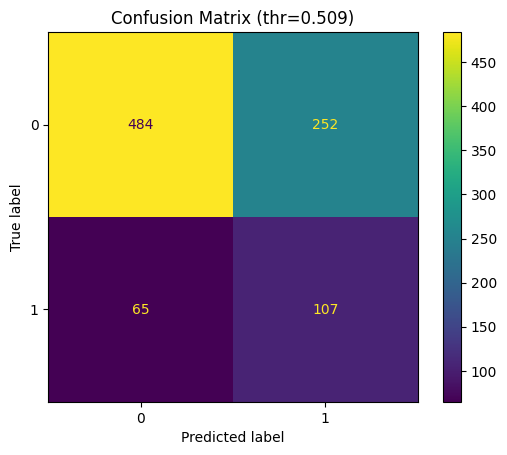

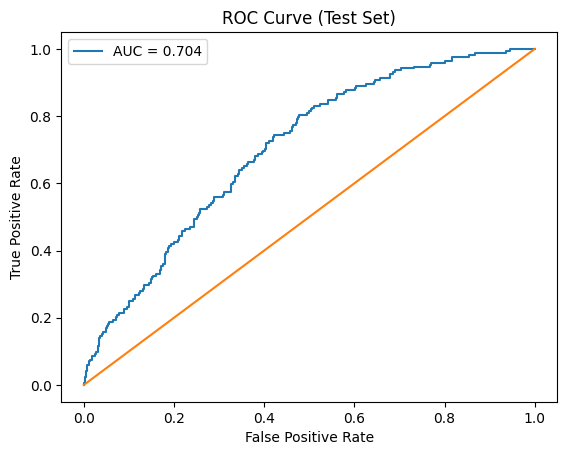

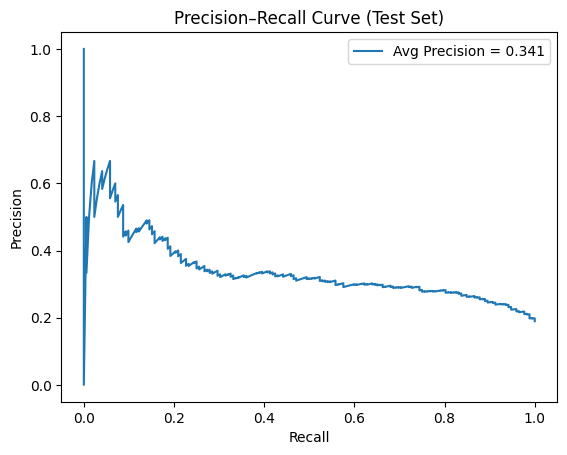

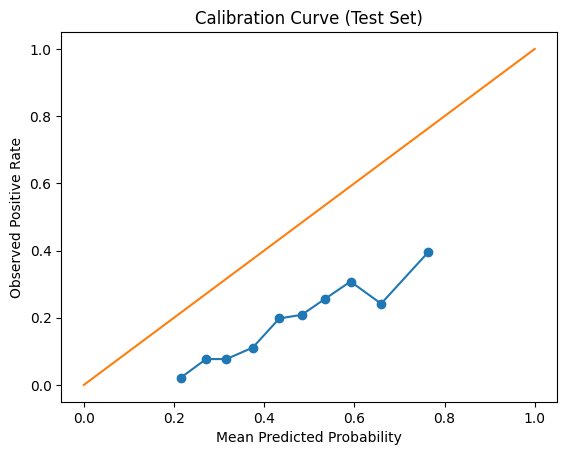

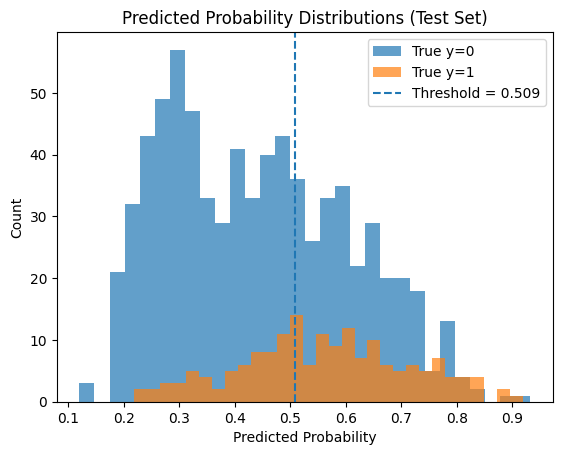

In [42]:

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 1) Probabilities + AUC
# ----------------------------
y_prob_test = pipe_lr_cv.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Threshold (Youden, TRAIN OOF):", round(best_thr, 4))
print("Confusion Matrix:\n", cm)
print("=======================================")

# ----------------------------
# 2) Colored Confusion Matrix (Matplotlib default colormap)
# ----------------------------
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(ax=ax)  # colored by default colormap
ax.set_title(f"Confusion Matrix (thr={best_thr:.3f})")
plt.show()

# ----------------------------
# 3) ROC Curve (with AUC shown)
# ----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])  # diagonal reference line (default style)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

# ----------------------------
# 4) Precision–Recall Curve (useful for imbalance)
# ----------------------------
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# ----------------------------
# 5) Calibration Curve (very useful under scrutiny)
# ----------------------------
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Calibration Curve (Test Set)")
plt.show()

# ----------------------------
# 6) Distribution of predicted probabilities (separation)
# ----------------------------
y_test_np = np.asarray(y_test)

plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Threshold = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

## ElasticNet


 Elastic Net Youden threshold (CV=5 OOF): 0.5114
 Youden J: 0.3621
 Sensitivity: 0.6829
 Specificity: 0.6792

 Elastic Net Test AUC: 0.7071

Confusion Matrix:
 [[496 240]
 [ 67 105]]

Classification Report:
               precision    recall  f1-score   support

           0      0.881     0.674     0.764       736
           1      0.304     0.610     0.406       172

    accuracy                          0.662       908
   macro avg      0.593     0.642     0.585       908
weighted avg      0.772     0.662     0.696       908



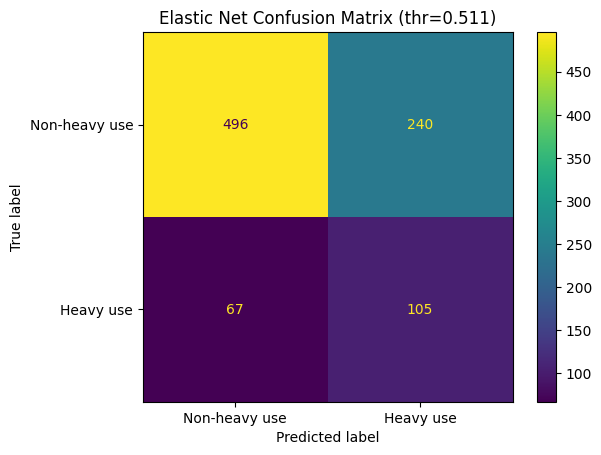

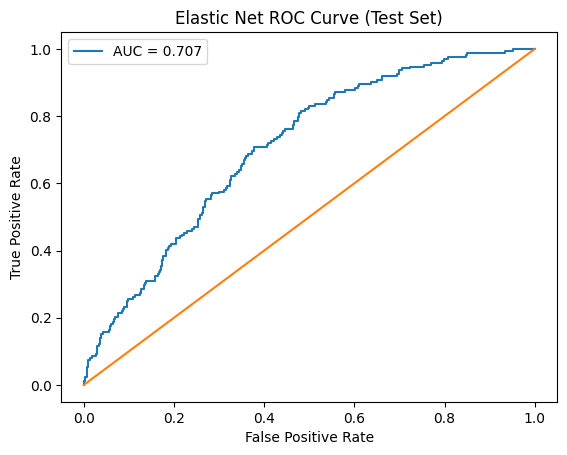

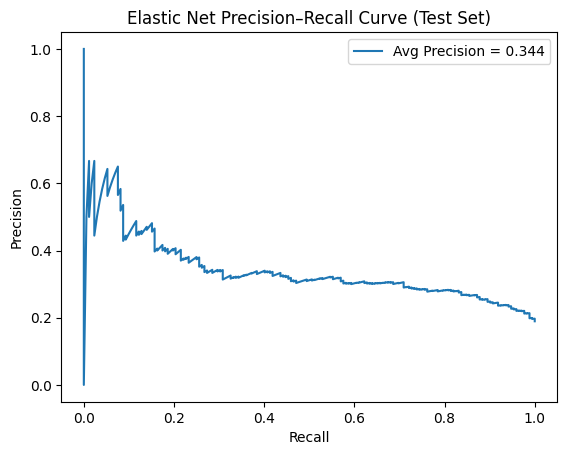

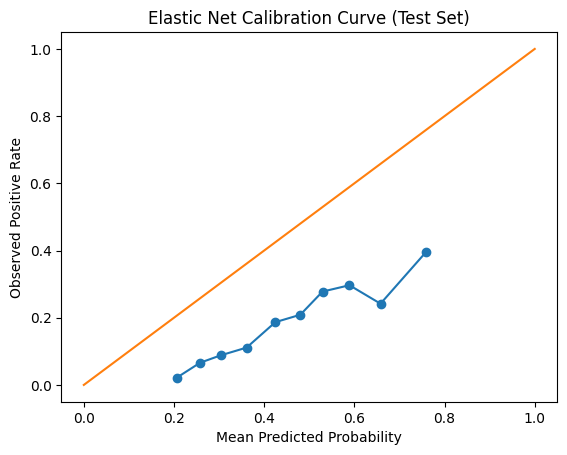


Top positive coefficients (risk factors):
                         feature      coef
16         EverTried_Cigarette_Z  0.137477
21        LowReligiosityIndex_W1  0.120050
3              Delinquency_Index  0.119712
17      Trouble Paying Attention  0.110165
19                Attractive_Sex  0.091569
2             SchoolSuspension_Z  0.073915
6            SchoolTrouble_Index  0.052179
1             SexAttitudes_Index  0.044265
12            Rev_FeelGuilty_Sex  0.040986
7            PeerSubstance_Index  0.040624
13                   Relax_Sex_Z  0.025393
23  Trouble_GetAlong_Teachers_W1  0.019410
20              ExpectCollege_W1  0.010410
14                   SoldDrugs_Z  0.005589
11                     GPA_Index  0.005517

Top negative coefficients (protective factors):
                    feature      coef
9            LessLonely_Sex  0.004576
27  DrinkFrequency_Past12mo  0.000695
26          WeaponThreat_W1  0.000000
4      SchoolBehavior_Index  0.000000
8            InjuredSomeone  0

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve



# ------------------------------------------------
# CV objects
# ------------------------------------------------
cv_tune = 3   # tuning
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------
# Elastic Net Logistic Regression (TUNED)
# ------------------------------------------------
pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 20),
        cv=cv_tune,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        refit=True
    ))
])

# Fit FINAL model on full training
pipe_en.fit(X_train2, y_train)

# ------------------------------------------------
# Youden threshold (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
oof_prob = cross_val_predict(
    pipe_en,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Elastic Net Youden threshold (CV=5 OOF):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")

# ------------------------------------------------
# Final TEST evaluation
# ------------------------------------------------
y_prob_test = pipe_en.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
y_pred_test = (y_prob_test >= best_thr).astype(int)

print("\n=======================================")
print(" Elastic Net Test AUC:", round(test_auc, 4))
print("=======================================")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))

# ------------------------------------------------
# FIGURES
# ------------------------------------------------

# 1) Confusion Matrix (colored)
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
disp.plot()
plt.title(f"Elastic Net Confusion Matrix (thr={best_thr:.3f})")
plt.show()

# 2) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Elastic Net ROC Curve (Test Set)")
plt.legend()
plt.show()

# 3) Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Elastic Net Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 4) Calibration Curve
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Elastic Net Calibration Curve (Test Set)")
plt.show()

# ------------------------------------------------
# Coefficients (interpretable output)
# ------------------------------------------------
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


In [44]:
import numpy as np
import pandas as pd

# Extract coefficients
lr_en = pipe_en.named_steps["lr"]
coefs = lr_en.coef_[0]

coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# Inspect
coef_df.head(10)


,feature,coef,abs_coef
0,Sex_Female,-0.522173,0.522173
5,Age at First Drink,-0.177486,0.177486
16,EverTried_Cigarette_Z,0.137477,0.137477
21,LowReligiosityIndex_W1,0.120050,0.120050
3,Delinquency_Index,0.119712,0.119712
17,Trouble Paying Attention,0.110165,0.110165
19,Attractive_Sex,0.091569,0.091569
24,Pleasure_Sex,-0.077876,0.077876
22,Fight_Serious_Z,-0.077283,0.077283
2,SchoolSuspension_Z,0.073915,0.073915


In [45]:
import numpy as np
import pandas as pd

# ============================================
# 1) Extract fitted Elastic Net model
# ============================================
lr_en = pipe_en.named_steps["lr"]

# Best hyperparameters
best_C = lr_en.C_[0]
best_l1 = lr_en.l1_ratio_[0]

print(f"Selected C: {best_C}")
print(f"Selected l1_ratio: {best_l1}")

# ============================================
# 2) Build FULL coefficient table
# ============================================
coef = lr_en.coef_[0]

en_table = pd.DataFrame({
    "Feature": X_train2.columns,
    "Coefficient": coef,
})

# Odds ratios
en_table["Odds_Ratio"] = np.exp(en_table["Coefficient"])

# Absolute magnitude (importance)
en_table["Abs_Coefficient"] = en_table["Coefficient"].abs()

# Direction
en_table["Direction"] = np.where(
    en_table["Coefficient"] > 0, "Risk-increasing", "Protective"
)

# Feature selection indicator
en_table["Selected"] = en_table["Coefficient"] != 0

# Rank by importance
en_table = en_table.sort_values("Abs_Coefficient", ascending=False)
en_table["Rank"] = range(1, len(en_table) + 1)

# ============================================
# 3) Separate retained vs dropped features
# ============================================
en_selected = en_table[en_table["Selected"]].copy()
en_dropped  = en_table[~en_table["Selected"]].copy()

print("\nNumber of retained features:", en_selected.shape[0])
print("Number of shrunk-to-zero features:", en_dropped.shape[0])

# ============================================
# 4) Display top effects
# ============================================
print("\nTop 15 risk-increasing predictors:")
print(
    en_selected[en_selected["Coefficient"] > 0]
    .head(15)[["Rank","Feature","Coefficient","Odds_Ratio"]]
)

print("\nTop 15 protective predictors:")
print(
    en_selected[en_selected["Coefficient"] < 0]
    .head(15)[["Rank","Feature","Coefficient","Odds_Ratio"]]
)



Selected C: 0.012742749857031334
Selected l1_ratio: 0.1

Number of retained features: 26
Number of shrunk-to-zero features: 4

Top 15 risk-increasing predictors:
    Rank                       Feature  Coefficient  Odds_Ratio
16     3         EverTried_Cigarette_Z     0.137477    1.147376
21     4        LowReligiosityIndex_W1     0.120050    1.127553
3      5             Delinquency_Index     0.119712    1.127173
17     6      Trouble Paying Attention     0.110165    1.116462
19     7                Attractive_Sex     0.091569    1.095893
2     10            SchoolSuspension_Z     0.073915    1.076715
6     13           SchoolTrouble_Index     0.052179    1.053564
1     14            SexAttitudes_Index     0.044265    1.045259
12    16            Rev_FeelGuilty_Sex     0.040986    1.041838
7     17           PeerSubstance_Index     0.040624    1.041461
13    19                   Relax_Sex_Z     0.025393    1.025718
23    20  Trouble_GetAlong_Teachers_W1     0.019410    1.019600
20    

## Random Forest

Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC: 0.7291925832886741

Best Parameters:
{'rf__n_estimators': 1600, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 10, 'rf__max_features': 'sqrt', 'rf__max_depth': 30, 'rf__class_weight': None}
Youden threshold (CV/OOF, train-only): 0.188

RANDOM FOREST — TUNED PERFORMANCE (YOUDEN)

ROC–AUC: 0.6946
PR–AUC : 0.3170
Best Threshold (Youden): 0.183

Confusion Matrix (at Youden threshold):
[[442 294]
 [ 51 121]] 

Classification Report (at Youden threshold):
              precision    recall  f1-score     support
0              0.896552  0.600543  0.719284  736.000000
1              0.291566  0.703488  0.412266  172.000000
accuracy       0.620044  0.620044  0.620044    0.620044
macro avg      0.594059  0.652016  0.565775  908.000000
weighted avg   0.781951  0.620044  0.661126  908.000000 

Final Performance Summary:
                Metric   Value
0    CV ROC–AUC (bes

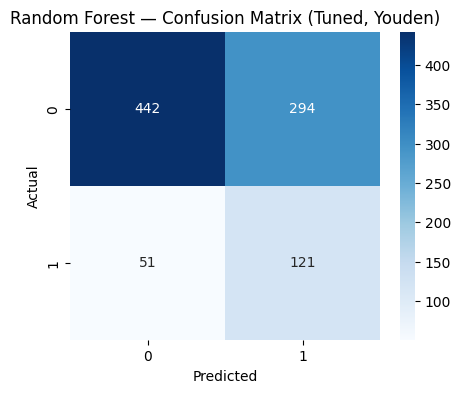

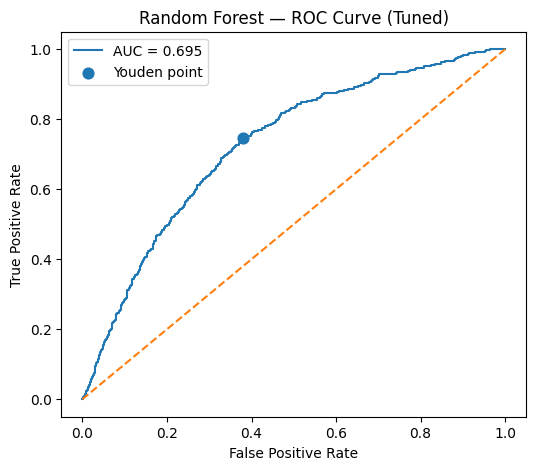

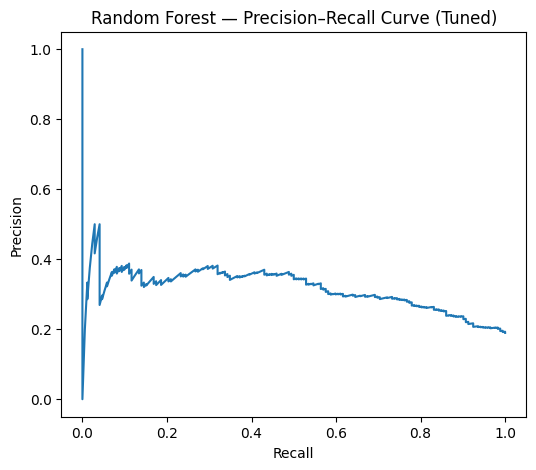


Best RF estimator:
RandomForestClassifier(max_depth=30, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=1600, n_jobs=-1, random_state=42)


In [18]:
# ============================================================
# RANDOM FOREST + HYPERPARAMETER TUNING + YOUDEN THRESHOLD
# (FULL, SINGLE-CELL CODE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 0) SETTINGS
# ============================================================

RANDOM_STATE = 42
CV_FOLDS = 3
N_ITER = 40

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ============================================================
# 1) PIPELINE + RANDOMIZED SEARCH (TUNING)
# ============================================================

pipe_rf = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "rf__n_estimators": [300, 500, 800, 1200, 1600],
    "rf__max_depth": [None, 10, 20, 30, 40],
    "rf__min_samples_split": [2, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4, 6, 10],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8, None],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

rs = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV for Random Forest...")
rs.fit(X_train, y_train)

print("\nBest CV AUC:", rs.best_score_)
print("\nBest Parameters:")
print(rs.best_params_)

best_pipe = rs.best_estimator_
best_rf = best_pipe.named_steps["rf"]
##########################################################################
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve
import numpy as np

cv_thr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    best_pipe,              # your tuned pipeline/model
    X_train, y_train,
    cv=cv_thr,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, oof_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
youden_threshold = thresholds[best_idx]

print("Youden threshold (CV/OOF, train-only):", round(youden_threshold, 3))
#################################################################################
best_pipe.fit(X_train, y_train)

y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= youden_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n===============================================")
print("RANDOM FOREST — TUNED PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"ROC–AUC: {roc_auc:.4f}")
print(f"PR–AUC : {pr_auc:.4f}")
print(f"Best Threshold (Youden): {best_threshold:.3f}\n")

print("Confusion Matrix (at Youden threshold):")
cm = confusion_matrix(y_test, y_pred)
print(cm, "\n")

print("Classification Report (at Youden threshold):")
print(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T, "\n")

performance_summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (best)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)",
        "Youden Threshold",
        "Youden J"
    ],
    "Value": [
        rs.best_score_,
        roc_auc,
        pr_auc,
        acc,
        prec,
        rec,
        f1,
        best_threshold,
        youden_j[best_idx]
    ]
}).round(4)

print("Final Performance Summary:")
print(performance_summary)

# Optional: show the top of the Youden table
print("\nTop Youden thresholds (top 10):")
print(youden_df.head(10))

# ============================================================
# 6) CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title("Random Forest — Confusion Matrix (Tuned, Youden)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================================
# 7) ROC CURVE PLOT
# ============================================================

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], marker="o", s=60, label="Youden point")
plt.title("Random Forest — ROC Curve (Tuned)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 8) PRECISION–RECALL CURVE PLOT
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title("Random Forest — Precision–Recall Curve (Tuned)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ============================================================
# 9) (OPTIONAL) SHOW BEST RF MODEL SUMMARY
# ============================================================

print("\nBest RF estimator:")
print(best_rf)


Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.7292
Best Parameters:
{'rf__n_estimators': 1600, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 10, 'rf__max_features': 'sqrt', 'rf__max_depth': 30, 'rf__class_weight': None}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.1882
Youden J (train OOF): 0.3659
Sensitivity (TPR) @ thr: 0.7451
Specificity (TNR) @ thr: 0.6208

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6946
Test PR–AUC : 0.3170
Threshold (Youden, from train OOF): 0.1882

Accuracy : 0.6200
Precision: 0.2916
Recall   : 0.7035
F1-score : 0.4123

Confusion Matrix (Test):
 [[442 294]
 [ 51 121]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.896552  0.600543  0.719284  736.000000
1              0.291566  0.703488  0.412266  172.000000
accuracy       0.620044  0.620044  0.620044    0.620044
macro

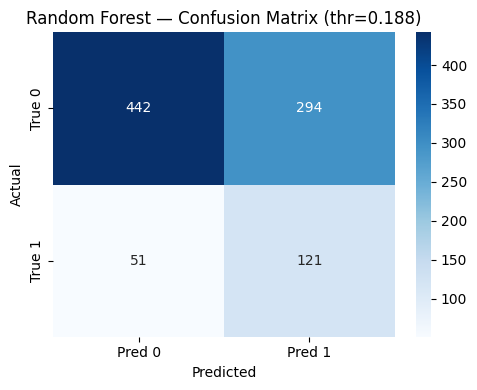

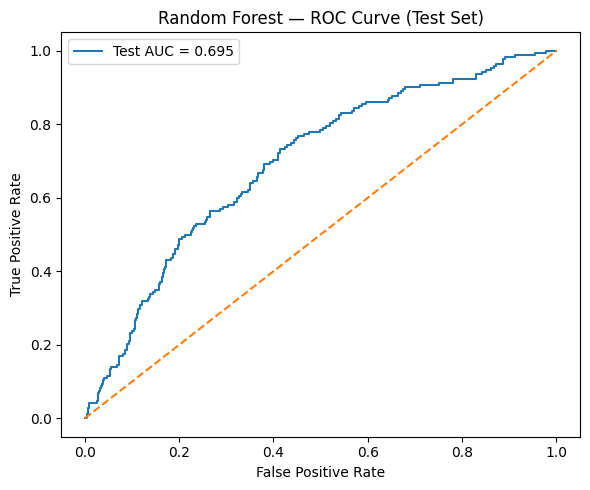

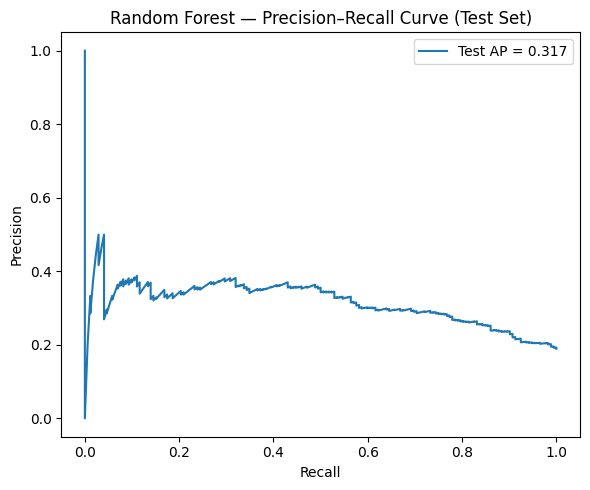

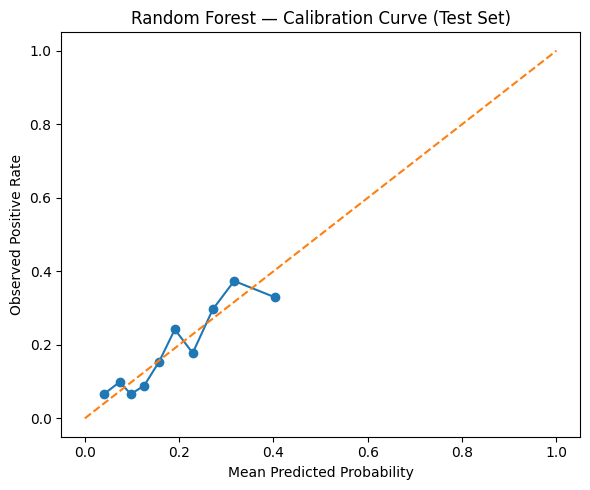

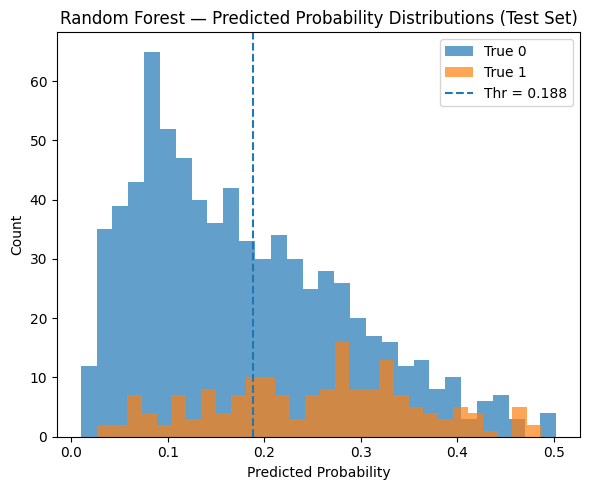


Best RF estimator:
RandomForestClassifier(max_depth=30, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=1600, n_jobs=-1, random_state=42)


In [46]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN THRESHOLD (CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (CM, ROC, PR, CALIBRATION)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

CV_TUNE_FOLDS = 3   # for hyperparameter tuning
CV_YOUDEN_FOLDS = 5 # for Youden threshold estimation (OOF)

N_ITER = 40

cv_tune = StratifiedKFold(n_splits=CV_TUNE_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_thr  = StratifiedKFold(n_splits=CV_YOUDEN_FOLDS, shuffle=True, random_state=RANDOM_STATE)


# ----------------------------
# 1) PIPELINE + RANDOMIZED SEARCH (TUNING)
# ----------------------------
pipe_rf = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "rf__n_estimators": [300, 500, 800, 1200, 1600],
    "rf__max_depth": [None, 10, 20, 30, 40],
    "rf__min_samples_split": [2, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4, 6, 10],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8, None],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

rs = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV for Random Forest...")
rs.fit(X_train, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_pipe = rs.best_estimator_  # tuned pipeline


# ----------------------------
# 2) YOUDEN THRESHOLD (CORRECT WAY): CV=5 OOF PROBS ON TRAIN ONLY
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

# OOF probabilities (train only)
oof_prob = cross_val_predict(
    best_pipe,
    X_train, y_train,
    cv=cv_thr,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_threshold, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_threshold, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 3) FIT FINAL MODEL ON FULL TRAIN, EVALUATE ON TEST ONCE
# ----------------------------
best_pipe.fit(X_train, y_train)

y_prob_test = best_pipe.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= youden_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_prob_test)
pr_auc  = average_precision_score(y_test, y_prob_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {roc_auc:.4f}")
print(f"Test PR–AUC : {pr_auc:.4f}")
print(f"Threshold (Youden, from train OOF): {youden_threshold:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)


# ----------------------------
# 4) PERFORMANCE SUMMARY TABLE
# ----------------------------
performance_summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_threshold,
        youden_j_best,
        roc_auc,
        pr_auc,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(performance_summary)


# ----------------------------
# 5) FIGURES
# ----------------------------

# 5.1 Confusion Matrix (colored)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)
plt.title(f"Random Forest — Confusion Matrix (thr={youden_threshold:.3f})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 5.2 ROC Curve (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# 5.3 Precision–Recall Curve (TEST)
precision, recall, _ = precision_recall_curve(y_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Test AP = {pr_auc:.3f}")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# 5.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.tight_layout()
plt.show()

# 5.5 Probability Distributions (TEST) with threshold line
y_test_np = np.asarray(y_test)

plt.figure(figsize=(6, 5))
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True 0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True 1")
plt.axvline(youden_threshold, linestyle="--", label=f"Thr = {youden_threshold:.3f}")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 6) OPTIONAL: show best RF model
# ----------------------------
print("\nBest RF estimator:")
print(best_pipe.named_steps["rf"])


In [17]:
X_train.isna().sum().sum()


np.int64(9882)

## Plain Logistic Regression

In [60]:
import pandas as pd
df_logit=df_all_filtered.copy()

In [61]:
df_logit=df_logit.drop(columns=['DaysMarijuanaPast12M_W4'])

In [62]:

keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df_logit.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [63]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "TotalDrinking"  
corr_thr = 0.05                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_logit.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_logit = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 89 vars with |corr| ≥ 0.050
[Step 2] Dropped 32 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 57

=== FINAL FEATURE SET ===
Variables kept (n=57):
Sex_Female
SchoolSuspension_Z
Age at First Drink
InjuredSomeone
LessLonely_Sex
FriendsRespect_Sex
GPA_Index
PeerWeed_Count
Rev_FeelGuilty_Sex
Relax_Sex_Z
SoldDrugs_Z
WantCollege_W1
EverTried_Cigarette_Z
Trouble Paying Attention
PhysicalFight_W1
Attractive_Sex
ExpectCollege_W1
Fight_Serious_Z
Trouble_GetAlong_Teachers_W1
Pleasure_Sex
LessReligiousServiceAttendance_W1
peer_alcohol_count
PeerCig_Count
FriendCare_W1
WeaponThreat_W1
DrinkFrequency_Past12mo
HighEduExpectations
Jumped_W1
HangoutFriends_W1
PublicRowdy_Z
LiftWeights_W1
GroupFight
LowImportance_Z
TroubleGetAlong_Students_W1
Trouble_HomeworkCompletion_W1
MotherEverSmoked
Rev_UpsetMother_Sex
HoursGames_W1
Age_FirstWholeCig
DrugsAvailable_Home
ClosenessToMother_W1
SchoolExpulsion_Z
DrinksPerOccasion_Past12mo_Z
Days_SmokedPast30_Z
Lifetime_Marijuana
Age_FirstDrin

In [64]:
df_logit["heavy_drinker"] = (df_logit["TotalDrinking"] > 40).astype(int)
y = df_logit["heavy_drinker"]

X = df_logit.drop(columns=["TotalDrinking", "heavy_drinker"])


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [66]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [67]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6927767947421638
Optimal threshold (Youden J): 0.1687

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.60      0.72       736
           1       0.30      0.73      0.42       172

    accuracy                           0.62       908
   macro avg       0.60      0.66      0.57       908
weighted avg       0.79      0.62      0.66       908


Confusion matrix:
 [[441 295]
 [ 47 125]]


In [68]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.613977,0.066537,2.768602e-20,0.541194
Age at First Drink,Age at First Drink,-0.174381,0.051286,6.735152e-04,0.839977
HangoutFriends_W1,HangoutFriends_W1,0.162894,0.057078,4.318576e-03,1.176912
Pleasure_Sex,Pleasure_Sex,-0.197023,0.072628,6.672375e-03,0.821172
Trouble Paying Attention,Trouble Paying Attention,0.168340,0.065224,9.852627e-03,1.183339
FriendCare_W1,FriendCare_W1,-0.138754,0.053861,9.991282e-03,0.870442
EverTried_Cigarette_Z,EverTried_Cigarette_Z,0.147166,0.062000,1.761348e-02,1.158547
HouseholdSmokes,HouseholdSmokes,0.103625,0.053603,5.321393e-02,1.109184
SchoolSuspension_Z,SchoolSuspension_Z,0.096676,0.057394,9.210026e-02,1.101503
LessReligiousServiceAttendance_W1,LessReligiousServiceAttendance_W1,0.098273,0.058906,9.525736e-02,1.103264


In [69]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.613977,0.066537,2.768602e-20,0.541194
Age at First Drink,Age at First Drink,-0.174381,0.051286,6.735152e-04,0.839977
HangoutFriends_W1,HangoutFriends_W1,0.162894,0.057078,4.318576e-03,1.176912
Pleasure_Sex,Pleasure_Sex,-0.197023,0.072628,6.672375e-03,0.821172
Trouble Paying Attention,Trouble Paying Attention,0.168340,0.065224,9.852627e-03,1.183339
FriendCare_W1,FriendCare_W1,-0.138754,0.053861,9.991282e-03,0.870442
EverTried_Cigarette_Z,EverTried_Cigarette_Z,0.147166,0.062000,1.761348e-02,1.158547
